# Wind Farm Power Forecasting
**Objective**: Hourly power output forecasting for 10 wind farms using IFS HRES weather forecasts  
**Inputs**: Dataset 1 (production + capacity), Dataset 2 (site coordinates), Dataset 3 (weather forecasts)  
**Target**: `capacity_factor = production / installed_capacity` (normalized, site-agnostic)  

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Plotting style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})
PALETTE = sns.color_palette('tab10', 10)

## Data Loading & Quality Assessment

In [46]:
# Data import 
datasets = {i: pd.read_parquet(f'data/dataset_{i}.parquet') for i in range(1, 4)}

# Ensure UTC datetime
datasets[3]['delivery_time'] = pd.to_datetime(datasets[3]['delivery_time'], utc=True)
datasets[1]['delivery_time'] = pd.to_datetime(datasets[1]['delivery_time'], utc=True)

for i, name in zip(range(1, 4), ['Production', 'Sites', 'Weather']):
    print(f'\n--- Dataset {i}: {name} ---')
    print(f'Shape: {datasets[i].shape}')
    print(datasets[i].dtypes)
    print(datasets[i].head(2))


--- Dataset 1: Production ---
Shape: (274800, 4)
site_name                          object
delivery_time         datetime64[ns, UTC]
production                        float64
installed_capacity                float64
dtype: object
                     site_name             delivery_time  production  \
0  Nobelwind Offshore Windpark 2022-12-31 23:00:00+00:00    162.7175   
1  Nobelwind Offshore Windpark 2023-01-01 00:00:00+00:00    162.6850   

   installed_capacity  
0               165.0  
1               165.0  

--- Dataset 2: Sites ---
Shape: (10, 3)
site_name     object
latitude     float64
longitude    float64
dtype: object
                     site_name  latitude  longitude
0  Nobelwind Offshore Windpark   51.6631     2.8339
1           Rentel Offshore WP   51.5910     2.9440

--- Dataset 3: Weather ---
Shape: (275280, 23)
site_name                            object
delivery_time           datetime64[ns, UTC]
wind_speed_10m                      float64
wind_speed_100m          

In [47]:
# Data quality 
def quality_report(df, name):
    missing = df.isnull().sum()
    missing_pct = 100 * missing / len(df)
    report = pd.DataFrame({
        'missing': missing,
        'missing_%': missing_pct.round(2),
        'dtype': df.dtypes,
        'nunique': df.nunique(),
    }).query('missing > 0 or True')
    print(f'\n--- Quality: {name} ---')
    print(report.to_string())
    return report

qr1 = quality_report(datasets[1], 'Production')
qr3 = quality_report(datasets[3], 'Weather')


--- Quality: Production ---
                    missing  missing_%                dtype  nunique
site_name                 0       0.00               object       10
delivery_time             0       0.00  datetime64[ns, UTC]    27480
production               96       0.03              float64    88404
installed_capacity        0       0.00              float64       10

--- Quality: Weather ---
                      missing  missing_%                dtype  nunique
site_name                   0        0.0               object       10
delivery_time               0        0.0  datetime64[ns, UTC]    27528
wind_speed_10m              0        0.0              float64    22493
wind_speed_100m             0        0.0              float64    30071
wind_direction_10m          0        0.0              float64    47318
wind_direction_100m         0        0.0              float64    56370
wind_gusts_10m              0        0.0              float64      307
temperature_2m              0   

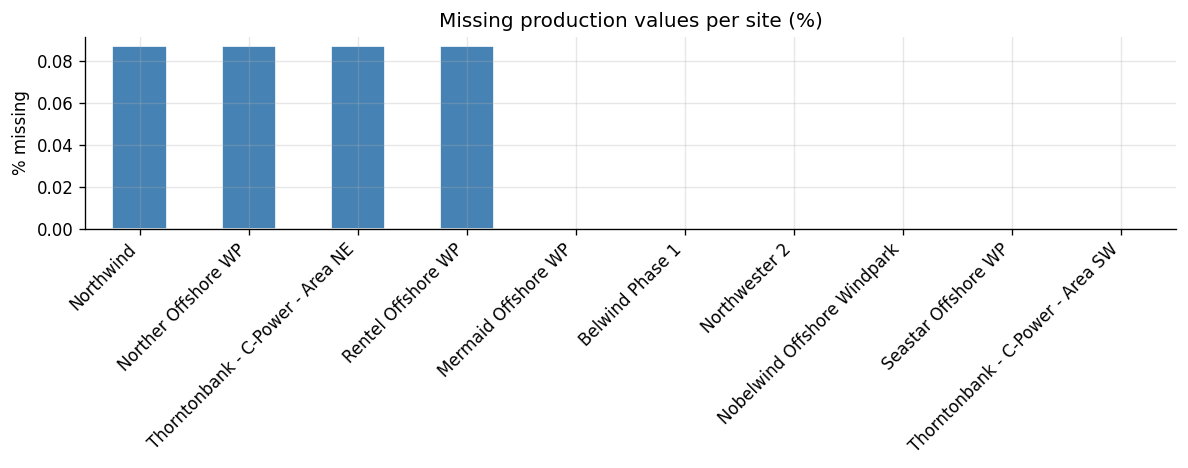

In [48]:
# Per-site missing production analysis
prod = datasets[1].copy()
null_by_site = (
    prod.groupby('site_name')['production']
    .apply(lambda x: 100 * x.isnull().sum() / len(x))
    .sort_values(ascending=False)
    .rename('missing_%')
)

fig, ax = plt.subplots(figsize=(10, 4))
null_by_site.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Missing production values per site (%)')
ax.set_xlabel('')
ax.set_ylabel('% missing')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Note: NaN production = turbine downtime / maintenance / curtailment

-> These rows will be **dropped** for training (we cannot learn from unknown targets

In [49]:
# Temporal coverage check
print('Production date range:\n', prod['delivery_time'].min(), '->', prod['delivery_time'].max())
print('Weather   date range:\n', datasets[3]['delivery_time'].min(), '->', datasets[3]['delivery_time'].max())
print('\nSites in production:\n', sorted(prod['site_name'].unique()))
print('Sites in weather:\n', sorted(datasets[3]['site_name'].unique()))

# Check for duplicate (site, time) pairs
dupes = prod.groupby(['site_name', 'delivery_time']).size()
print(f'\nDuplicate (site, time) in production: {(dupes > 1).sum()}')
dupes3 = datasets[3].groupby(['site_name', 'delivery_time']).size()
print(f'Duplicate (site, time) in weather:    {(dupes3 > 1).sum()}')

Production date range:
 2022-12-31 23:00:00+00:00 -> 2026-02-18 22:00:00+00:00
Weather   date range:
 2023-01-01 00:00:00+00:00 -> 2026-02-20 23:00:00+00:00

Sites in production:
 ['Belwind Phase 1', 'Mermaid Offshore WP', 'Nobelwind Offshore Windpark', 'Norther Offshore WP', 'Northwester 2', 'Northwind', 'Rentel Offshore WP', 'Seastar Offshore WP', 'Thorntonbank - C-Power - Area NE', 'Thorntonbank - C-Power - Area SW']
Sites in weather:
 ['Belwind Phase 1', 'Mermaid Offshore WP', 'Nobelwind Offshore Windpark', 'Norther Offshore WP', 'Northwester 2', 'Northwind', 'Rentel Offshore WP', 'Seastar Offshore WP', 'Thorntonbank - C-Power - Area NE', 'Thorntonbank - C-Power - Area SW']

Duplicate (site, time) in production: 0
Duplicate (site, time) in weather:    0


## Datasets Concatenation

In [50]:
# Merge all datasets
df = (
    datasets[1]
    .merge(datasets[3], on=['site_name', 'delivery_time'], how='inner')
    .merge(datasets[2], on='site_name', how='left')
    .sort_values(['site_name', 'delivery_time'])
    .reset_index(drop=True)
)

# Capacity factor (target)
df['capacity_factor'] = df['production'] / df['installed_capacity']

print(f'Merged shape: {df.shape}')
print(f'Date range:   {df.delivery_time.min()} -> {df.delivery_time.max()}')
print(f'Sites:        {df.site_name.nunique()}')
print(f'\nCapacity factor stats:')
print(df['capacity_factor'].describe().round(3))

# Rows with valid target
df_clean = df.dropna(subset=['capacity_factor']).copy()
print(f'\nRows with valid production: {len(df_clean):,} / {len(df):,} ({100*len(df_clean)/len(df):.1f}%)')

Merged shape: (274790, 28)
Date range:   2023-01-01 00:00:00+00:00 -> 2026-02-18 22:00:00+00:00
Sites:        10

Capacity factor stats:
count    274694.000
mean          0.364
std           0.344
min           0.000
25%           0.050
50%           0.239
75%           0.689
max           0.991
Name: capacity_factor, dtype: float64

Rows with valid production: 274,694 / 274,790 (100.0%)


## EDA

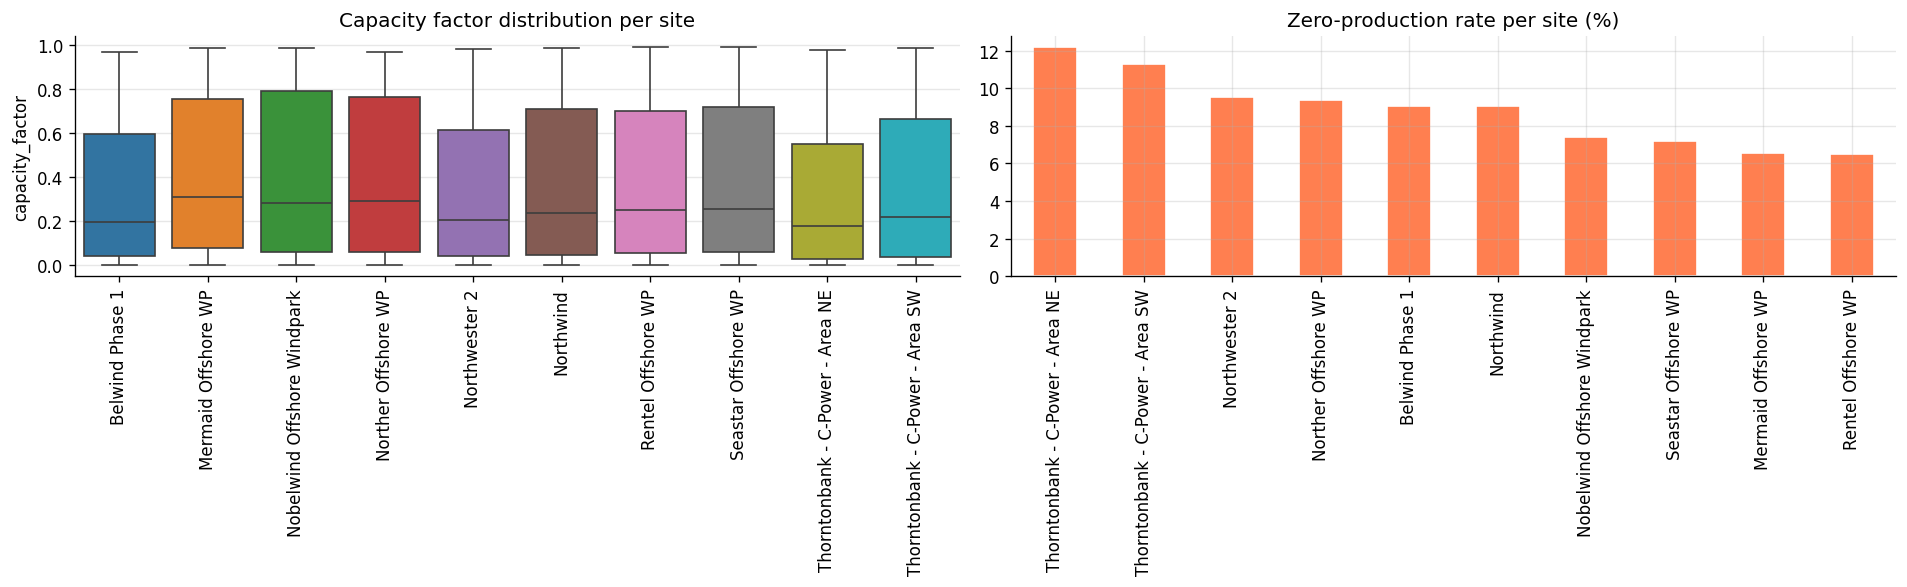

In [51]:
# Capacity factor (target) distribution per site 
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(data=df_clean, x='site_name', y='capacity_factor', ax=axes[0],
            palette='tab10', fliersize=1)
axes[0].set_title('Capacity factor distribution per site')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=90)

# Zero-production rate
zero_rate = df_clean.groupby('site_name').apply(
    lambda x: 100 * (x['capacity_factor'] == 0).mean()
).sort_values(ascending=False)
zero_rate.plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Zero-production rate per site (%)')
axes[1].tick_params(axis='x', rotation=90)
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

Sites with low median → underperforming

Wide spread → unstable production

Many zeros → downtime or intermittency

Different shapes → different physics (wind regimes)

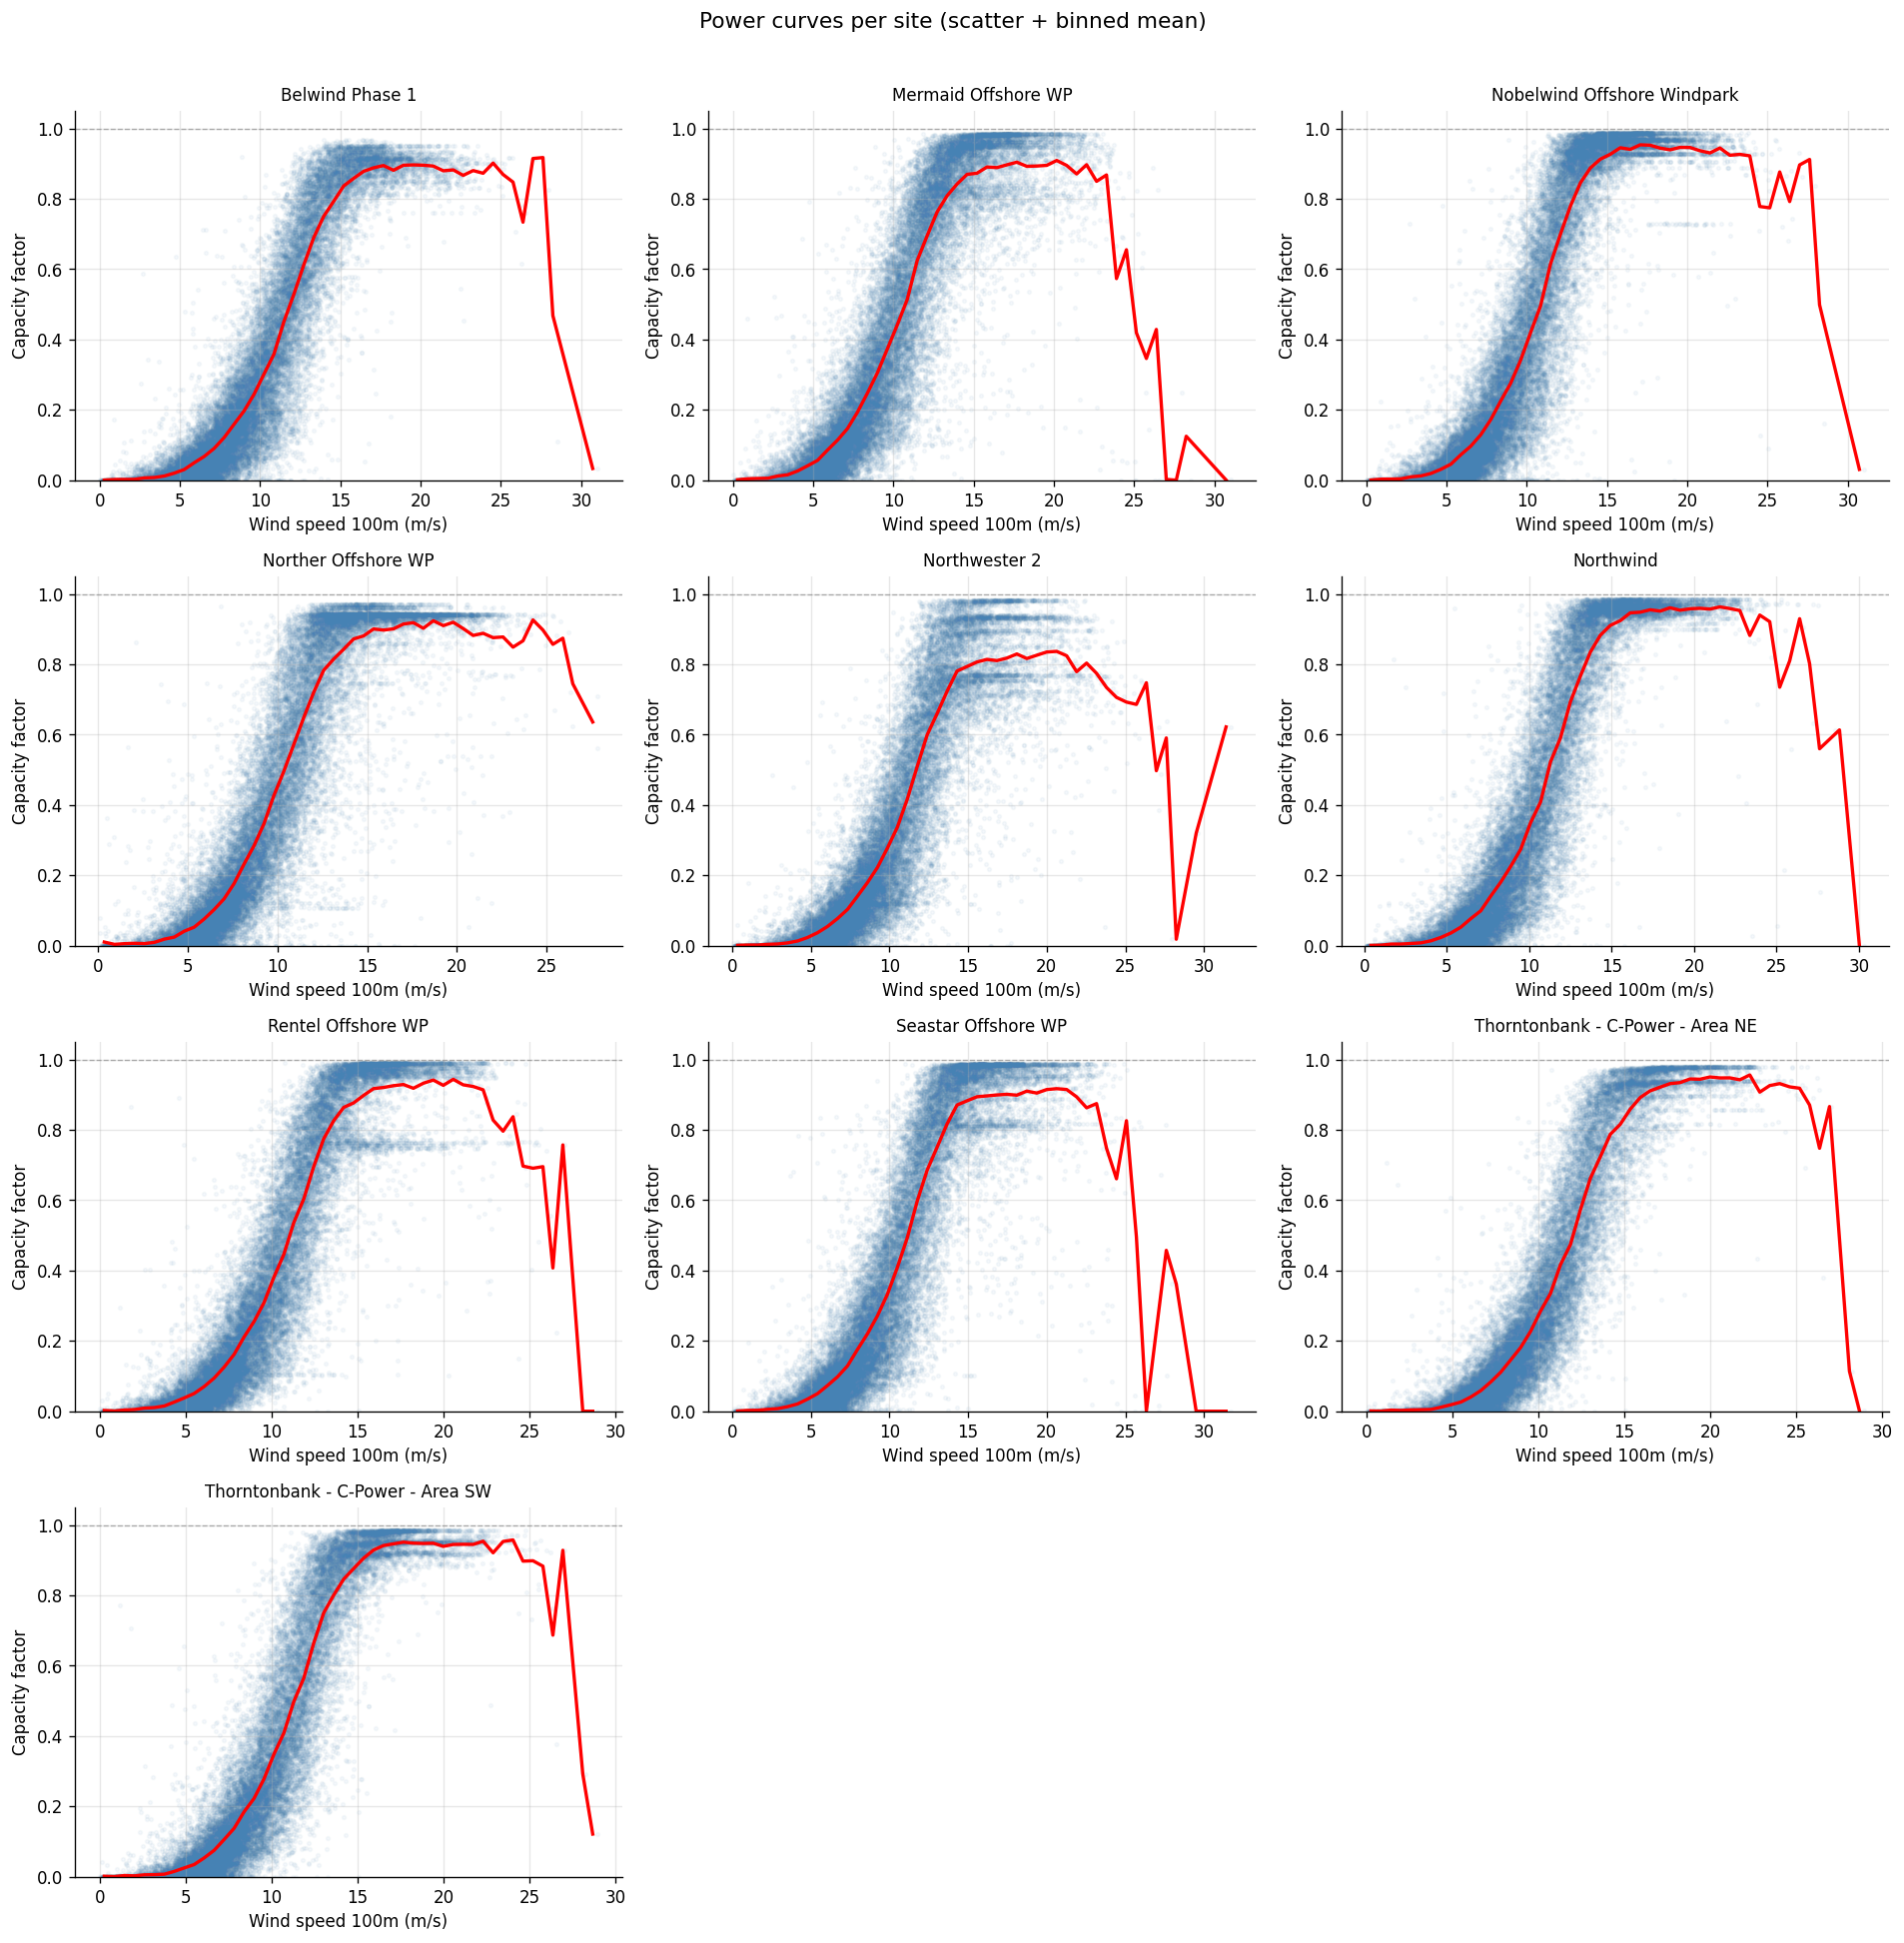

In [52]:
# Power curves (wind speed vs CF) per site
# Use binned mean to show the S-curve clearly
sites = sorted(df_clean['site_name'].unique())
n_sites = len(sites)
ncols = 3
nrows = (n_sites + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
axes = axes.flatten()

for i, site in enumerate(sites):
    sub = df_clean[df_clean['site_name'] == site].copy()
    # Bin wind speed
    sub['ws_bin'] = pd.cut(sub['wind_speed_100m'], bins=50)
    binned = sub.groupby('ws_bin', observed=True)['capacity_factor'].mean().reset_index()
    binned['ws_mid'] = binned['ws_bin'].apply(lambda x: x.mid)

    ax = axes[i]
    ax.scatter(sub['wind_speed_100m'].sample(min(50000, len(sub)), random_state=0),
               sub['capacity_factor'].sample(min(50000, len(sub)), random_state=0),
               alpha=0.05, s=5, color='steelblue')
    ax.plot(binned['ws_mid'], binned['capacity_factor'], color='red', lw=2, label='Binned mean')
    ax.set_title(site, fontsize=10)
    ax.set_xlabel('Wind speed 100m (m/s)')
    ax.set_ylabel('Capacity factor')
    ax.set_ylim(0, 1.05)
    ax.axhline(1.0, color='gray', ls='--', lw=0.8, alpha=0.6)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Power curves per site (scatter + binned mean)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

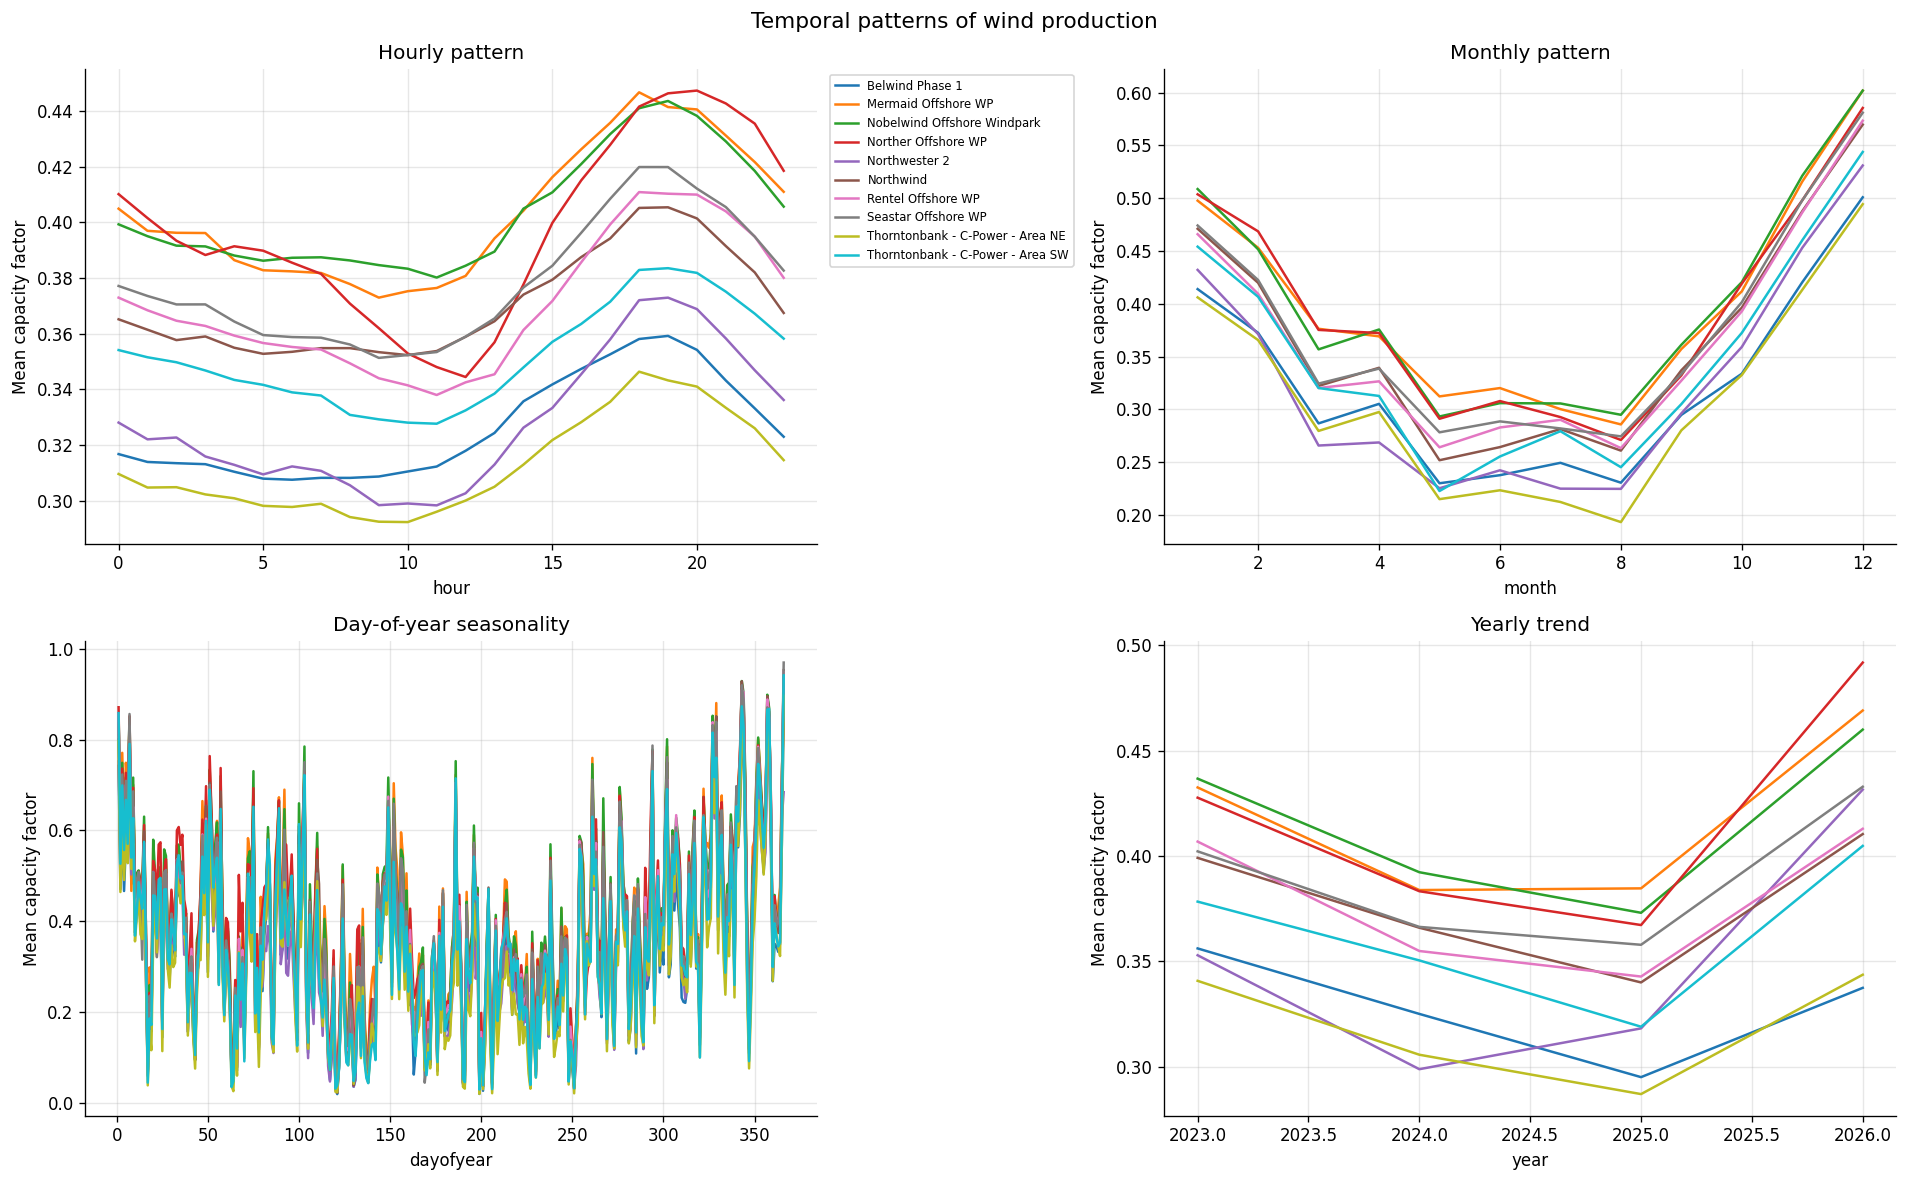

In [53]:
# Seasonal patterns
df_clean['hour'] = df_clean['delivery_time'].dt.hour
df_clean['month'] = df_clean['delivery_time'].dt.month
df_clean['dayofyear'] = df_clean['delivery_time'].dt.dayofyear
df_clean['year'] = df_clean['delivery_time'].dt.year

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, (x_col, title) in zip(axes.flatten(), [
    ('hour', 'Hourly pattern'),
    ('month', 'Monthly pattern'),
    ('dayofyear', 'Day-of-year seasonality'),
    ('year', 'Yearly trend'),
]):
    monthly = df_clean.groupby(['site_name', x_col])['capacity_factor'].mean().reset_index()
    sns.lineplot(data=monthly, x=x_col, y='capacity_factor', hue='site_name',
                 ax=ax, legend=(x_col == 'hour'), palette='tab10')
    ax.set_title(title)
    ax.set_ylabel('Mean capacity factor')
    if x_col == 'hour':
        ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7)

plt.suptitle('Temporal patterns of wind production', fontsize=13)
plt.tight_layout()
plt.show()

Weather variables: ['wind_speed_10m', 'wind_speed_100m', 'wind_direction_10m', 'wind_direction_100m', 'wind_gusts_10m', 'temperature_2m', 'dewpoint_2m', 'apparent_temperature', 'pressure_msl', 'surface_pressure', 'precipitation', 'snowfall', 'cloud_cover', 'cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_high', 'shortwave_radiation', 'direct_radiation', 'diffuse_radiation', 'weather_code', 'sunshine_duration']


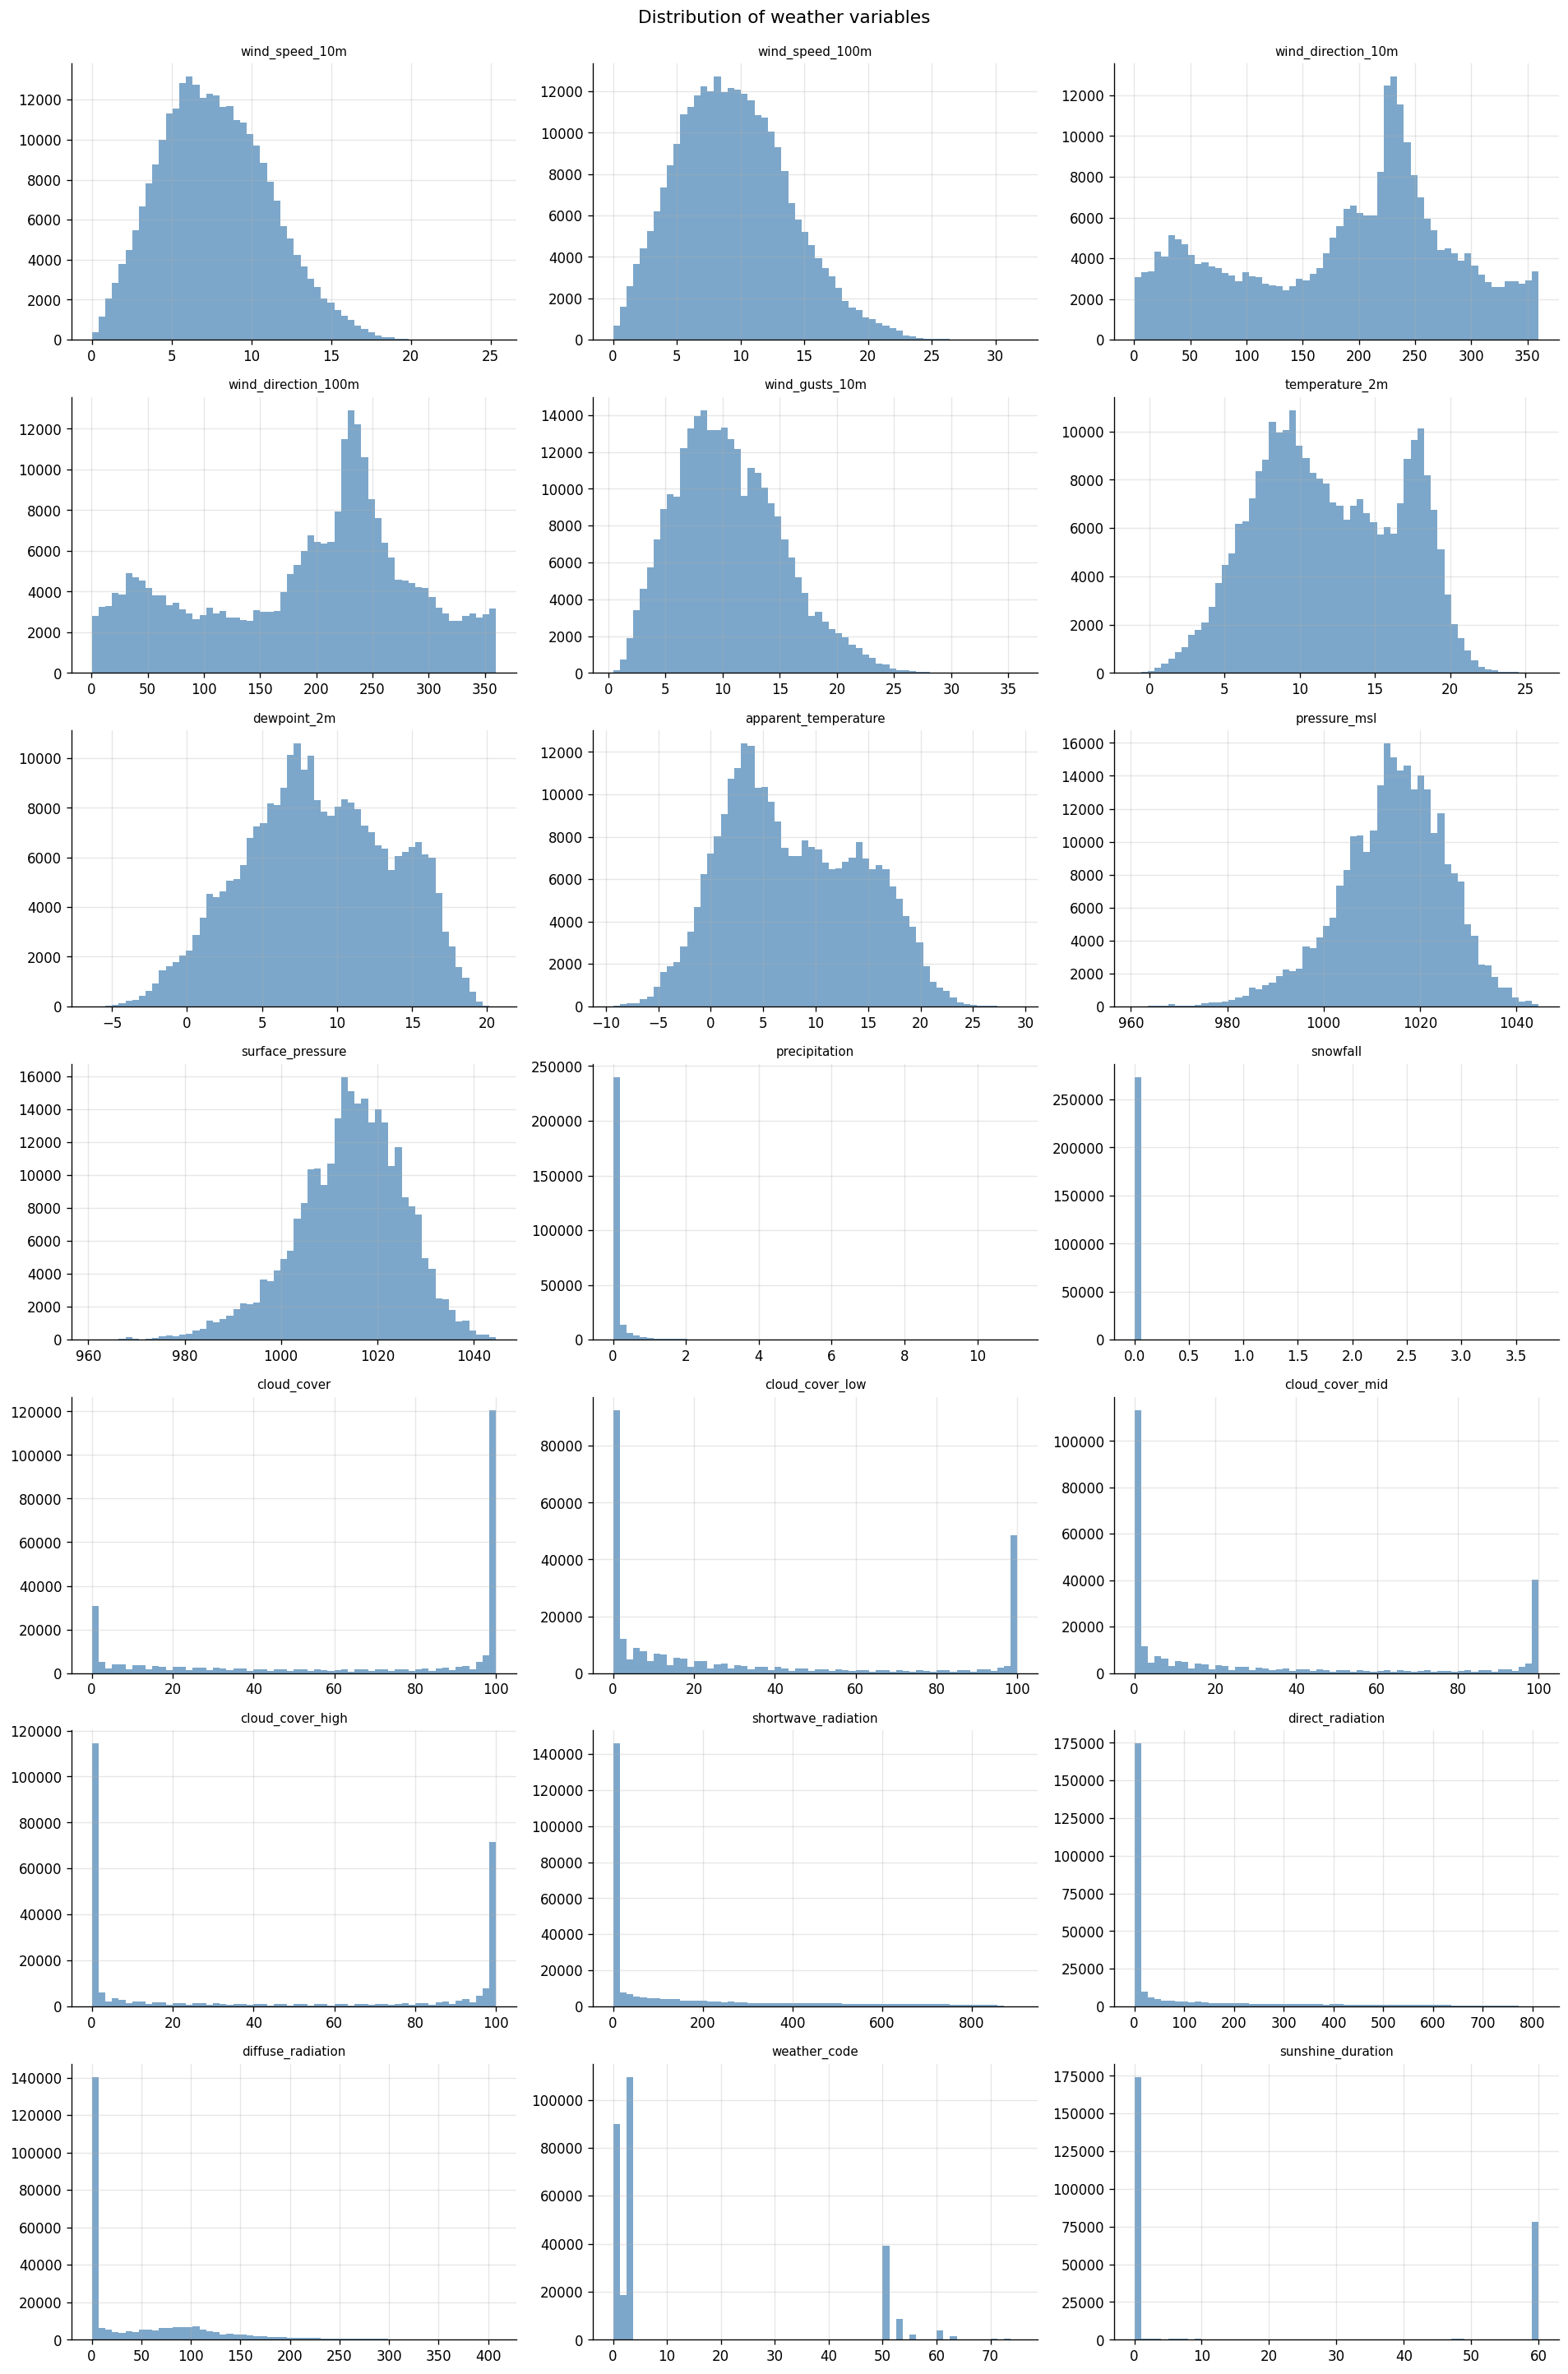

In [54]:
# 3.4  Weather variable distributions
# Identify weather columns
meta_cols = ['site_name', 'delivery_time', 'production', 'installed_capacity',
             'capacity_factor', 'latitude', 'longitude', 'hour', 'month',
             'dayofyear', 'year']
weather_cols = [c for c in df_clean.columns if c not in meta_cols]
print('Weather variables:', weather_cols)

n = len(weather_cols)
ncols = 3
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.5))
axes = axes.flatten()

for i, col in enumerate(weather_cols):
    axes[i].hist(df_clean[col].dropna(), bins=60, color='steelblue', edgecolor='none', alpha=0.7)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of weather variables\n\n', fontsize=13)
plt.tight_layout()
plt.show()

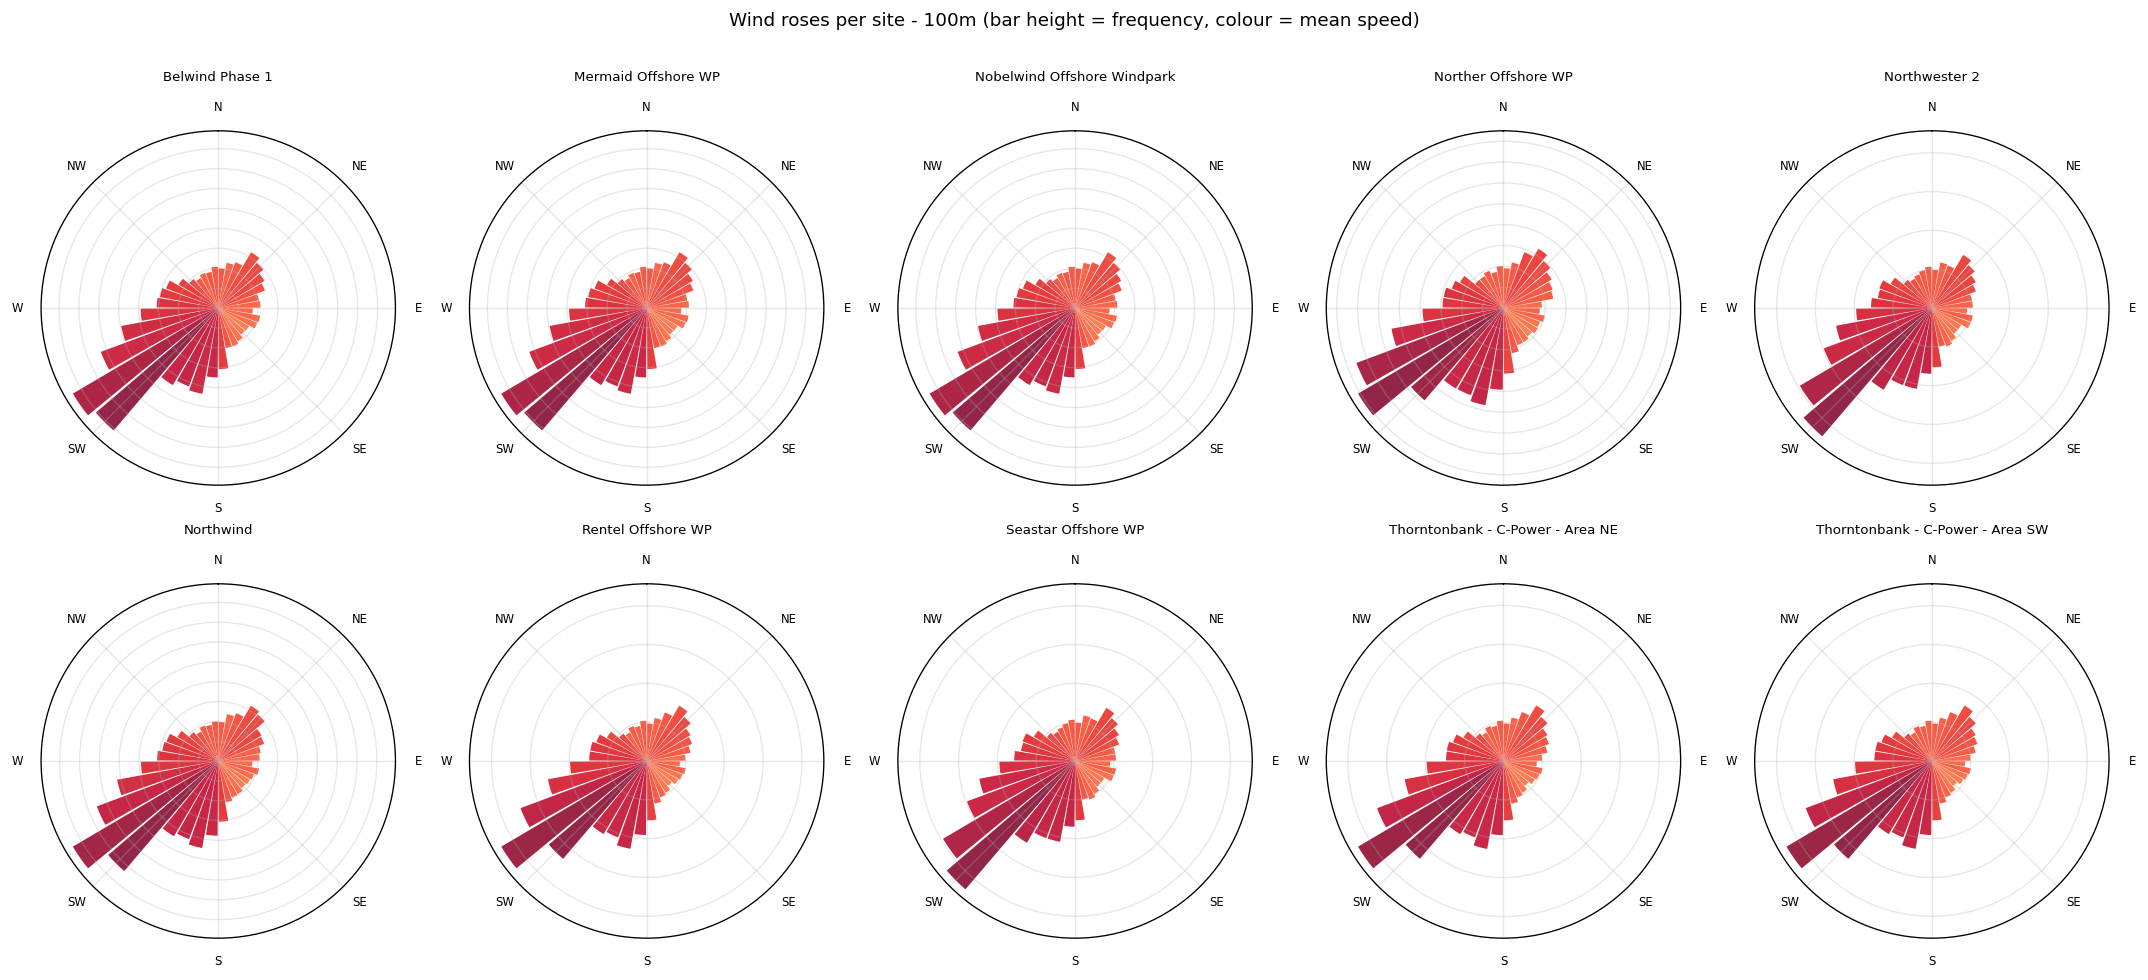

In [55]:
# Wind rose - direction vs speed per site
fig, axes = plt.subplots(2, 5, figsize=(18, 8), subplot_kw=dict(projection='polar'))
n_bins = 36
dir_bins = np.linspace(0, 360, n_bins + 1)

for ax, site in zip(axes.flatten(), sites):
    sub = df_clean[df_clean['site_name'] == site].dropna(subset=['wind_direction_100m', 'wind_speed_100m'])
    # Bin directions
    sub = sub.copy()
    sub['dir_bin'] = pd.cut(sub['wind_direction_100m'], bins=dir_bins, labels=False, include_lowest=True)
    grouped = sub.groupby('dir_bin', observed=True).agg(
        count=('wind_speed_100m', 'count'),
        mean_ws=('wind_speed_100m', 'mean')
    ).reindex(range(n_bins), fill_value=0)

    theta = np.radians(dir_bins[:-1] + 5)  # centre of each bin
    width = 2 * np.pi / n_bins
    bars = ax.bar(theta, grouped['count'], width=width * 0.9,
                  bottom=0, edgecolor='none', alpha=0.85)
    # Colour by mean wind speed
    ws_norm = grouped['mean_ws'] / (grouped['mean_ws'].max() + 1e-6)
    cmap = plt.cm.YlOrRd
    for bar, norm_val in zip(bars, ws_norm):
        bar.set_facecolor(cmap(norm_val))

    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)  # clockwise = meteorological convention
    ax.set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'], fontsize=7)
    ax.set_yticklabels([])
    ax.set_title(site, fontsize=8, pad=12)

plt.suptitle('Wind roses per site - 100m (bar height = frequency, colour = mean speed)', fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

Top correlations with capacity_factor:
wind_speed_100m         0.882
wind_speed_10m          0.882
wind_gusts_10m          0.871
apparent_temperature   -0.348
pressure_msl           -0.322
surface_pressure       -0.322
weather_code            0.250
cloud_cover_mid         0.224
direct_radiation       -0.169
shortwave_radiation    -0.166
wind_direction_10m      0.162
wind_direction_100m     0.155
cloud_cover_low         0.146
sunshine_duration      -0.144
precipitation           0.142
Name: capacity_factor, dtype: float64


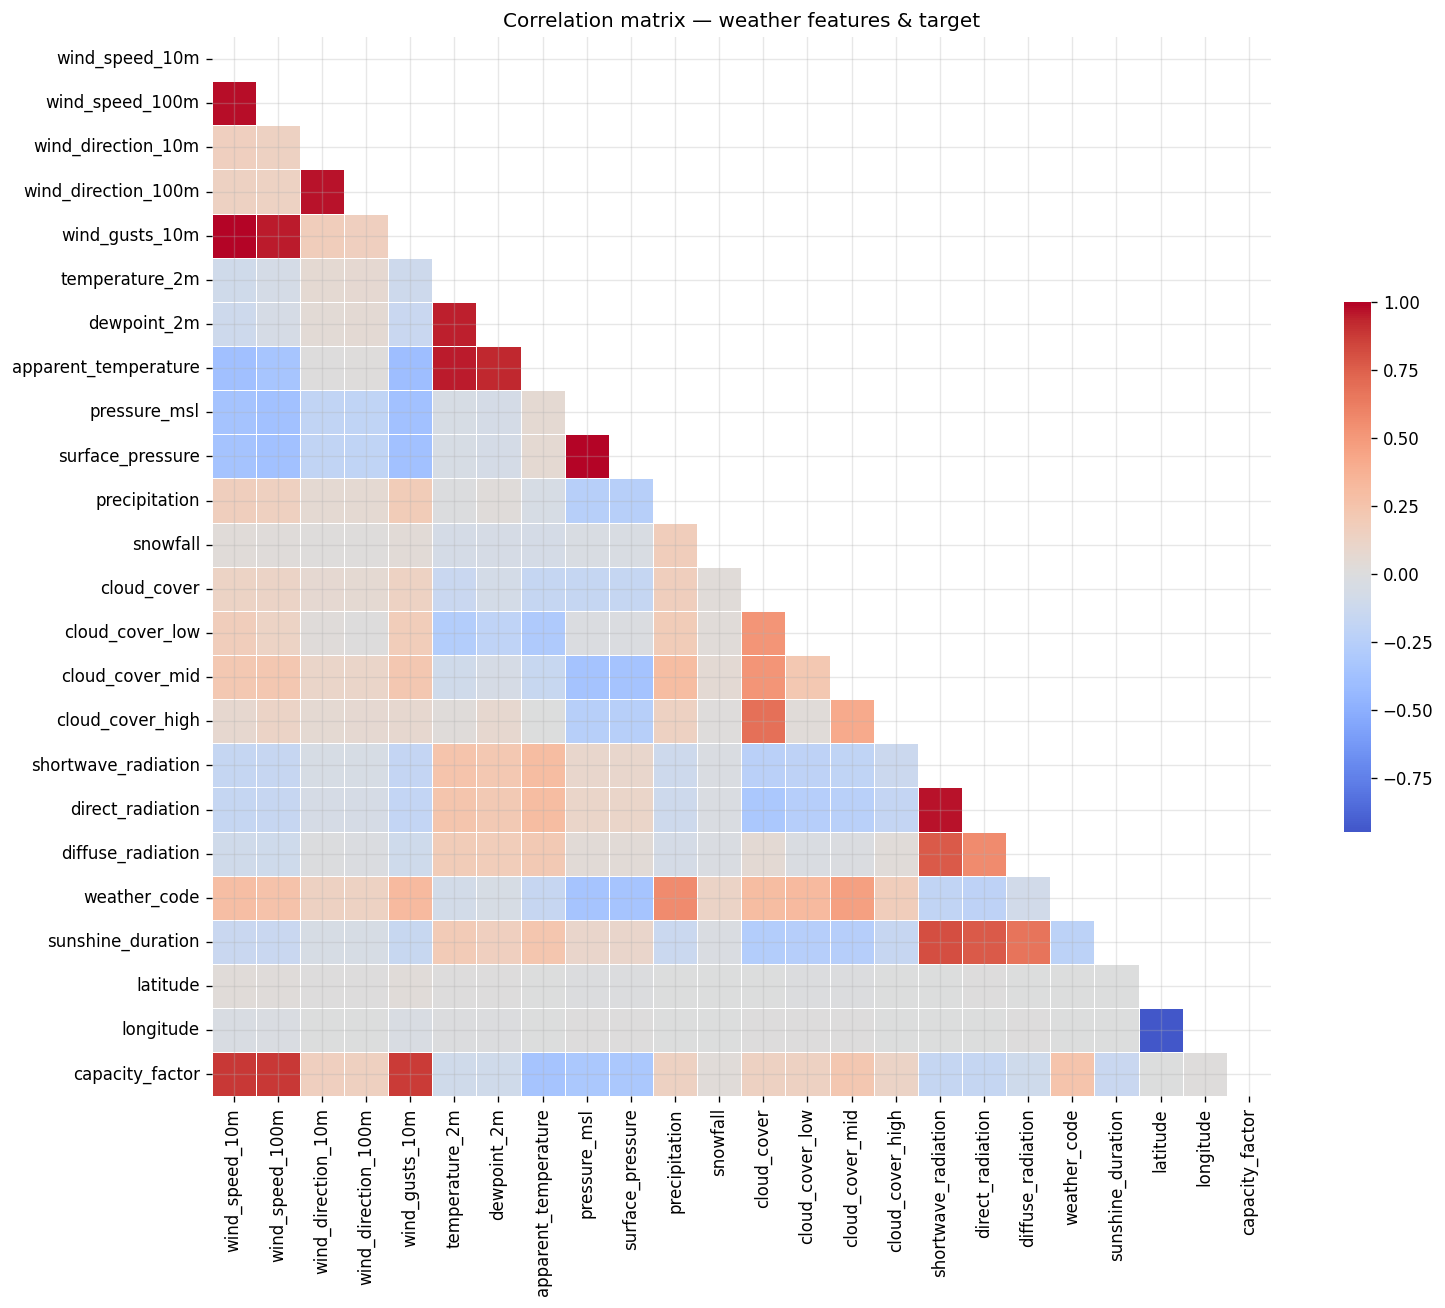

In [56]:
# Correlation matrix (weather vs target)
num_df = df_clean.select_dtypes(include='number').drop(
    columns=['production', 'installed_capacity', 'hour', 'month', 'dayofyear', 'year'],
    errors='ignore'
)

corr = num_df.corr()

# Show only correlations with capacity_factor, sorted
cf_corr = corr['capacity_factor'].drop('capacity_factor').sort_values(key=abs, ascending=False)
print('Top correlations with capacity_factor:')
print(cf_corr.head(15).round(3))

# Full heatmap
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0, annot=False,
            square=True, linewidths=0.3, ax=ax, cbar_kws={'shrink': 0.5})
ax.set_title('Correlation matrix — weather features & target', fontsize=12)
plt.tight_layout()
plt.show()

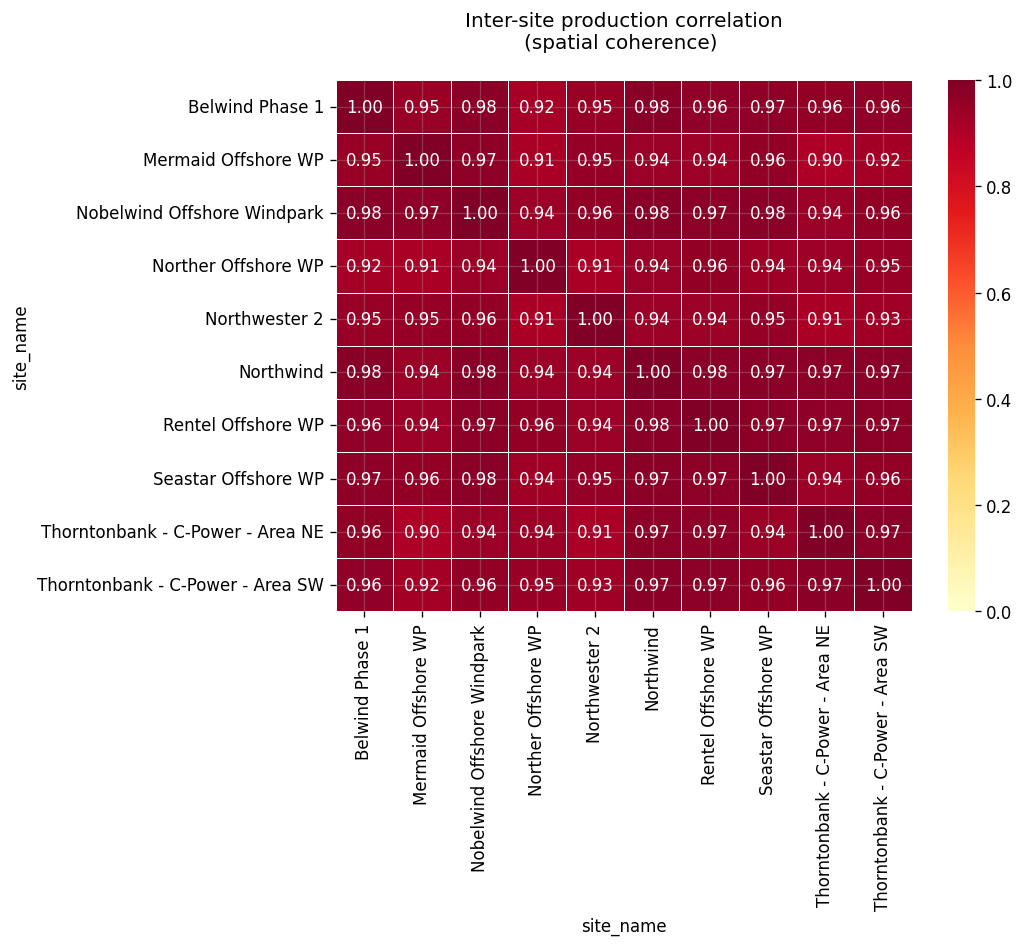

In [57]:
# Inter-site correlation (spatial coherence)
pivot_cf = df_clean.pivot_table(
    index='delivery_time', columns='site_name', values='capacity_factor'
)
site_corr = pivot_cf.corr()

fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(site_corr, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax,
            vmin=0, vmax=1, linewidths=0.5)
ax.set_title('Inter-site production correlation\n(spatial coherence) \n', fontsize=12)
plt.tight_layout()
plt.show()

Highly correlated sites share similar wind regimes -> a global model will leverage this

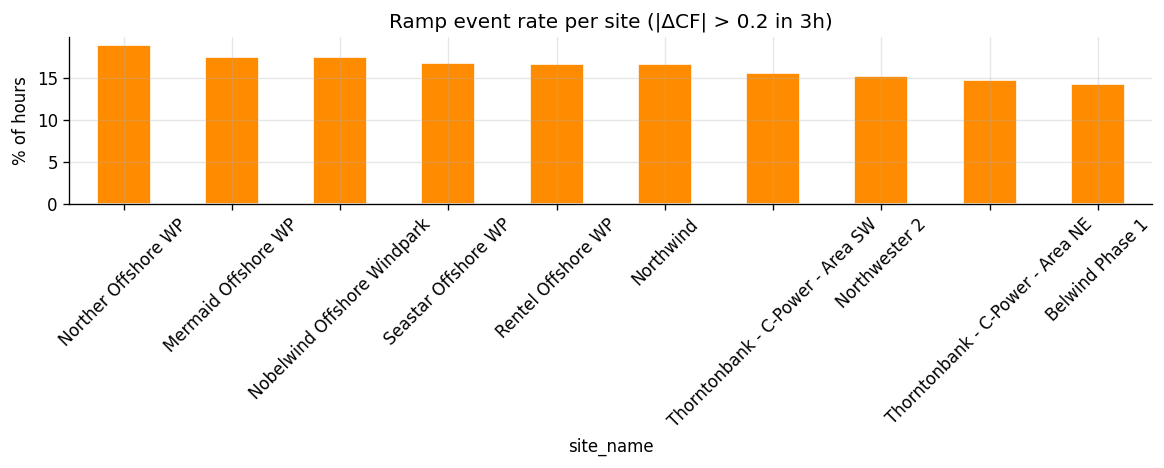

In [58]:
# Ramp events analysis
# A ramp event = large change in production within 1–6h
df_clean = df_clean.sort_values(['site_name', 'delivery_time'])
df_clean['cf_diff_1h'] = df_clean.groupby('site_name')['capacity_factor'].diff(1)
df_clean['cf_diff_3h'] = df_clean.groupby('site_name')['capacity_factor'].diff(3)
df_clean['cf_diff_6h'] = df_clean.groupby('site_name')['capacity_factor'].diff(6)

RAMP_THRESH = 0.20  # 20% capacity factor change
ramp_rate = (
    df_clean.groupby('site_name')['cf_diff_3h']
    .apply(lambda x: 100 * (x.abs() > RAMP_THRESH).mean())
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 4))
ramp_rate.plot(kind='bar', ax=ax, color='darkorange', edgecolor='white')
ax.set_title(f'Ramp event rate per site (|ΔCF| > {RAMP_THRESH} in 3h)')
ax.set_ylabel('% of hours')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

Sites with high ramp rates are harder to forecast -> expect higher nRMSE

## Feature Engineering

In [59]:
fe = df_clean.copy()

# Temporal features
dt = fe['delivery_time']
fe['hour']       = dt.dt.hour
fe['dayofweek']  = dt.dt.dayofweek
fe['dayofyear']  = dt.dt.dayofyear
fe['month']      = dt.dt.month
fe['year']       = dt.dt.year
fe['quarter']    = dt.dt.quarter
fe['is_weekend'] = (dt.dt.dayofweek >= 5).astype(int)

# Cyclic encoding
for col, period in [('hour', 24), ('dayofweek', 7), ('dayofyear', 365), ('month', 12)]:
    fe[f'{col}_sin'] = np.sin(2 * np.pi * fe[col] / period)
    fe[f'{col}_cos'] = np.cos(2 * np.pi * fe[col] / period)

In [60]:
# Wind physics features
# Dataset has: wind_speed_10m, wind_speed_100m, wind_direction_10m, wind_direction_100m
# wind_gusts_10m

for height in ['10m', '100m']:
    ws  = f'wind_speed_{height}'
    wd  = f'wind_direction_{height}'
    tag = height.replace('m', '')

    # Power curve physics: power ∝ v³ in ramp-up regime
    fe[f'ws_{tag}_sq']    = fe[ws] ** 2
    fe[f'ws_{tag}_cubed'] = fe[ws] ** 3

    # Cyclic encoding of wind direction (avoids 0/360 discontinuity)
    fe[f'wd_{tag}_sin'] = np.sin(np.radians(fe[wd]))
    fe[f'wd_{tag}_cos'] = np.cos(np.radians(fe[wd]))

    # Wind vector components (useful for directional models)
    fe[f'u_{tag}'] = -fe[ws] * np.sin(np.radians(fe[wd]))  # zonal (meteorological convention)
    fe[f'v_{tag}'] = -fe[ws] * np.cos(np.radians(fe[wd]))  # meridional

# Wind shear: ratio of 100m to 10m speed (atmospheric stability proxy)
fe['wind_shear'] = fe['wind_speed_100m'] / (fe['wind_speed_10m'] + 1e-6)

# Gust factor: gust vs mean speed (turbulence intensity proxy)
fe['gust_factor'] = fe['wind_gusts_10m'] / (fe['wind_speed_10m'] + 1e-6)

# Interaction: high-speed wind from favourable direction (site-agnostic feature)
fe['ws100_x_wd_cos'] = fe['wind_speed_100m'] * fe['wd_100_cos']
fe['ws100_x_wd_sin'] = fe['wind_speed_100m'] * fe['wd_100_sin']

# Atmosphere: humidity proxy
fe['temp_dewpoint_delta'] = fe['temperature_2m'] - fe['dewpoint_2m']  # dew point depression

# Air density proxy: higher density → more power at same wind speed
# Approximate: rho ∝ P / T  (using surface pressure and temperature in K)
fe['air_density_proxy'] = fe['surface_pressure'] / (fe['temperature_2m'] + 273.15)

# Effective wind power = air density × v³  (dimensionally consistent)
fe['effective_wind_power'] = fe['air_density_proxy'] * fe['ws_100_cubed']

print('Wind physics features added:')
new_cols = [c for c in fe.columns if any(x in c for x in ['ws_', 'wd_', 'u_', 'v_', 'shear', 'gust', 'air_density', 'effective'])]
print(new_cols)

Wind physics features added:
['wind_gusts_10m', 'ws_10_sq', 'ws_10_cubed', 'wd_10_sin', 'wd_10_cos', 'u_10', 'v_10', 'ws_100_sq', 'ws_100_cubed', 'wd_100_sin', 'wd_100_cos', 'u_100', 'v_100', 'wind_shear', 'gust_factor', 'ws100_x_wd_cos', 'ws100_x_wd_sin', 'air_density_proxy', 'effective_wind_power']


In [61]:
# Lag and rolling features
# Lags on weather forecasts are operationally valid at inference time
# Do NOT use production lags — we don't have future production at deployment

fe = fe.sort_values(['site_name', 'delivery_time']).reset_index(drop=True)

main_ws = 'wind_speed_100m'  # primary wind speed variable

for lag in [1, 2, 3, 6, 12, 24]:
    fe[f'ws100_lag{lag}h'] = fe.groupby('site_name')[main_ws].shift(lag)

for window in [3, 6, 12, 24]:
    fe[f'ws100_roll{window}h_mean'] = (
        fe.groupby('site_name')[main_ws]
        .transform(lambda x: x.rolling(window, min_periods=1).mean())
    )
    fe[f'ws100_roll{window}h_std'] = (
        fe.groupby('site_name')[main_ws]
        .transform(lambda x: x.rolling(window, min_periods=1).std().fillna(0))
    )

# Delta wind speed (forecast ramp - change over next hours)
fe['ws100_delta1h'] = fe.groupby('site_name')[main_ws].diff(1)
fe['ws100_delta3h'] = fe.groupby('site_name')[main_ws].diff(3)
fe['ws100_delta6h'] = fe.groupby('site_name')[main_ws].diff(6)

# Same lags for gusts (captures turbulent events)
for lag in [1, 3, 6]:
    fe[f'gusts_lag{lag}h'] = fe.groupby('site_name')['wind_gusts_10m'].shift(lag)
print('Lag cols:', [c for c in fe.columns if 'lag' in c or 'roll' in c or 'delta' in c])

Lag cols: ['temp_dewpoint_delta', 'ws100_lag1h', 'ws100_lag2h', 'ws100_lag3h', 'ws100_lag6h', 'ws100_lag12h', 'ws100_lag24h', 'ws100_roll3h_mean', 'ws100_roll3h_std', 'ws100_roll6h_mean', 'ws100_roll6h_std', 'ws100_roll12h_mean', 'ws100_roll12h_std', 'ws100_roll24h_mean', 'ws100_roll24h_std', 'ws100_delta1h', 'ws100_delta3h', 'ws100_delta6h', 'gusts_lag1h', 'gusts_lag3h', 'gusts_lag6h']


In [62]:
# Site climatological features
# Long-run average CF per (site, month, hour) - useful as a prior
clim = (
    fe.groupby(['site_name', 'month', 'hour'])['capacity_factor']
    .mean()
    .rename('cf_climatology')
    .reset_index()
)
fe = fe.merge(clim, on=['site_name', 'month', 'hour'], how='left')

# Residual from climatology (what the weather adds beyond seasonal norm)
fe['cf_clim_residual'] = fe['capacity_factor'] - fe['cf_climatology']

# Geographic features
# latitude/longitude already in df; add interaction with wind direction
if 'latitude' in fe.columns:
    fe['lat_rad'] = np.radians(fe['latitude'])
    fe['lon_rad'] = np.radians(fe['longitude'])

In [63]:
# Site encoding
fe['site_id'] = fe['site_name'].astype('category').cat.codes

# Final feature list
DROP_COLS = [
    'delivery_time', 'production', 'installed_capacity', 'site_name',
    'cf_diff_1h', 'cf_diff_3h', 'cf_diff_6h', 'cf_clim_residual',  # derived from target
]
TARGET = 'capacity_factor'

FEATURE_COLS = [
    c for c in fe.columns
    if c not in DROP_COLS + [TARGET]
    and fe[c].dtype in ['float64', 'float32', 'int64', 'int32']
]

print(f'\nTotal features: {len(FEATURE_COLS)}')
print('\nFeature list:')
for c in FEATURE_COLS:
    print(f'  {c}')


Total features: 80

Feature list:
  wind_speed_10m
  wind_speed_100m
  wind_direction_10m
  wind_direction_100m
  wind_gusts_10m
  temperature_2m
  dewpoint_2m
  apparent_temperature
  pressure_msl
  surface_pressure
  precipitation
  snowfall
  cloud_cover
  cloud_cover_low
  cloud_cover_mid
  cloud_cover_high
  shortwave_radiation
  direct_radiation
  diffuse_radiation
  weather_code
  sunshine_duration
  latitude
  longitude
  hour
  month
  dayofyear
  year
  dayofweek
  quarter
  is_weekend
  hour_sin
  hour_cos
  dayofweek_sin
  dayofweek_cos
  dayofyear_sin
  dayofyear_cos
  month_sin
  month_cos
  ws_10_sq
  ws_10_cubed
  wd_10_sin
  wd_10_cos
  u_10
  v_10
  ws_100_sq
  ws_100_cubed
  wd_100_sin
  wd_100_cos
  u_100
  v_100
  wind_shear
  gust_factor
  ws100_x_wd_cos
  ws100_x_wd_sin
  temp_dewpoint_delta
  air_density_proxy
  effective_wind_power
  ws100_lag1h
  ws100_lag2h
  ws100_lag3h
  ws100_lag6h
  ws100_lag12h
  ws100_lag24h
  ws100_roll3h_mean
  ws100_roll3h_std
  ws1